<a href="https://colab.research.google.com/github/twishaa05/Plant-Disease-Recognition---CNN/blob/main/AML_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

def count_images(folder_paths):
    for label, path in folder_paths.items():
        num_files = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        print(f"Number of {label}: {num_files}")

# Define paths
train_paths = {
    'healthy leaf images in training set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Train/Healthy",
    'powdery leaf images in training set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Train/Powdery",
    'rusty leaf images in training set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Train/Rust"
}

test_paths = {
    'healthy leaf images in test set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Test/Healthy",
    'powdery leaf images in test set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Test/Powdery",
    'rusty leaf images in test set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Test/Rust"
}

validation_paths = {
    'healthy leaf images in validation set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Validation/Healthy",
    'powdery leaf images in validation set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Validation/Powdery",
    'rusty leaf images in validation set': "/content/drive/MyDrive/plant-disease-recognition-dataset/Validation/Rust"
}

# Count and print the images in each set
print("Training Set:")
count_images(train_paths)

print("\nTest Set:")
count_images(test_paths)

print("\nValidation Set:")
count_images(validation_paths)


Training Set:
Number of healthy leaf images in training set: 458
Number of powdery leaf images in training set: 430
Number of rusty leaf images in training set: 434

Test Set:
Number of healthy leaf images in test set: 50
Number of powdery leaf images in test set: 50
Number of rusty leaf images in test set: 50

Validation Set:
Number of healthy leaf images in validation set: 20
Number of powdery leaf images in validation set: 20
Number of rusty leaf images in validation set: 20


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [ ]:
# Image Data Generators for data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale for validation data
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale for test data

# Data generators for training, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/plant-disease-recognition-dataset/Train",  # Training data path
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical'  # Multi-class classification
)

valid_generator = valid_datagen.flow_from_directory(
    "/content/drive/MyDrive/plant-disease-recognition-dataset/Validation",  # Validation data path
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/plant-disease-recognition-dataset/Test",  # Test data path
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [ ]:
model = models.Sequential()

# 1st Convolutional Layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# 2nd Convolutional Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# 3rd Convolutional Layer
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output for the fully connected layer
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(128, activation='relu'))

# Output layer (for multi-class classification)
model.add(layers.Dense(3, activation='softmax'))  # 3 classes: Healthy, Powdery, Rusty

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
results = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 812s 20s/step - accuracy: 0.4031 - loss: 1.8783 - val_accuracy: 0.7188 - val_loss: 0.6247
Epoch 2/20
 1/41 ━━━━━━━━━━━━━━━━━━━━ 3:33 5s/step - accuracy: 0.5938 - loss: 0.7745

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.5938 - loss: 0.7745 - val_accuracy: 0.4375 - val_loss: 1.2475
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 241s 6s/step - accuracy: 0.6798 - loss: 0.7090 - val_accuracy: 0.7188 - val_loss: 0.5647
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8438 - loss: 0.3983 - val_accuracy: 0.8125 - val_loss: 0.4144
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 262s 6s/step - accuracy: 0.8154 - loss: 0.4672 - val_accuracy: 0.8438 - val_loss: 0.5326
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.8438 - loss: 0.3955 - val_accuracy: 0.8750 - val_loss: 0.4763
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.8493 - loss: 0.4369 - val_accuracy: 0.8438 - val_loss: 0.3619
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8125 - loss: 0.4507 - val_accuracy: 0.6875 - val_loss: 0.6706
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.8874 - loss: 0.3308 - val_accuracy: 0.7812 - val_loss: 

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy: {test_acc * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 57s 14s/step - accuracy: 0.9344 - loss: 0.1993
Test accuracy: 92.97%


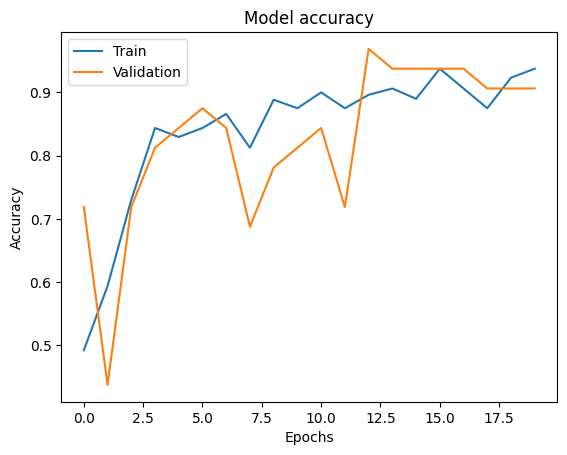

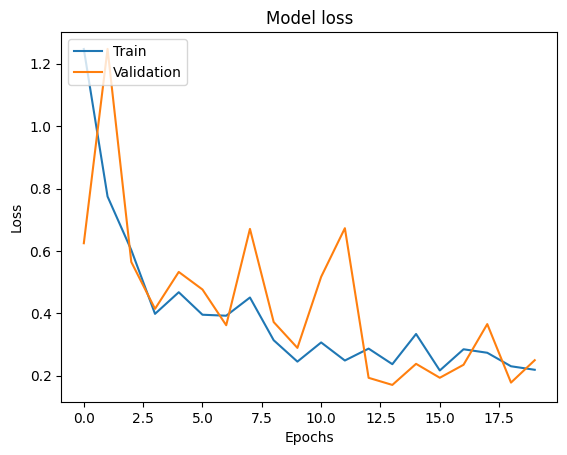

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
